## Load Data

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/news.csv")
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


## Basic Exploration 

In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

### Missing Value Handling

In [4]:
df.isnull().sum()
df = df.dropna(subset=["headline", "date", "publisher"])

## Headline Length

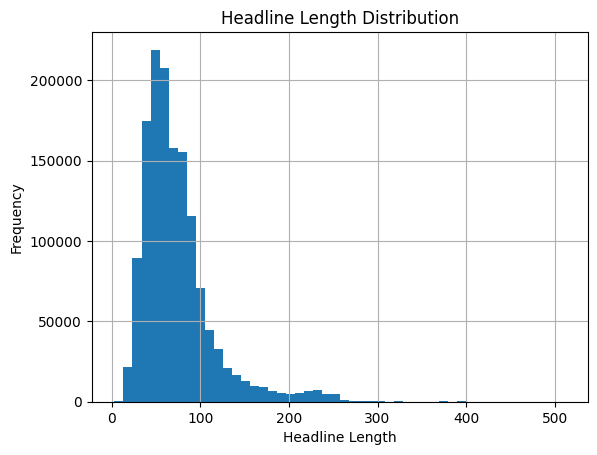

In [5]:
df["headline_length"] = df["headline"].str.len()

df["headline_length"].describe()

import matplotlib.pyplot as plt

df["headline_length"].hist(bins=50)
plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

## Publisher Analyisis

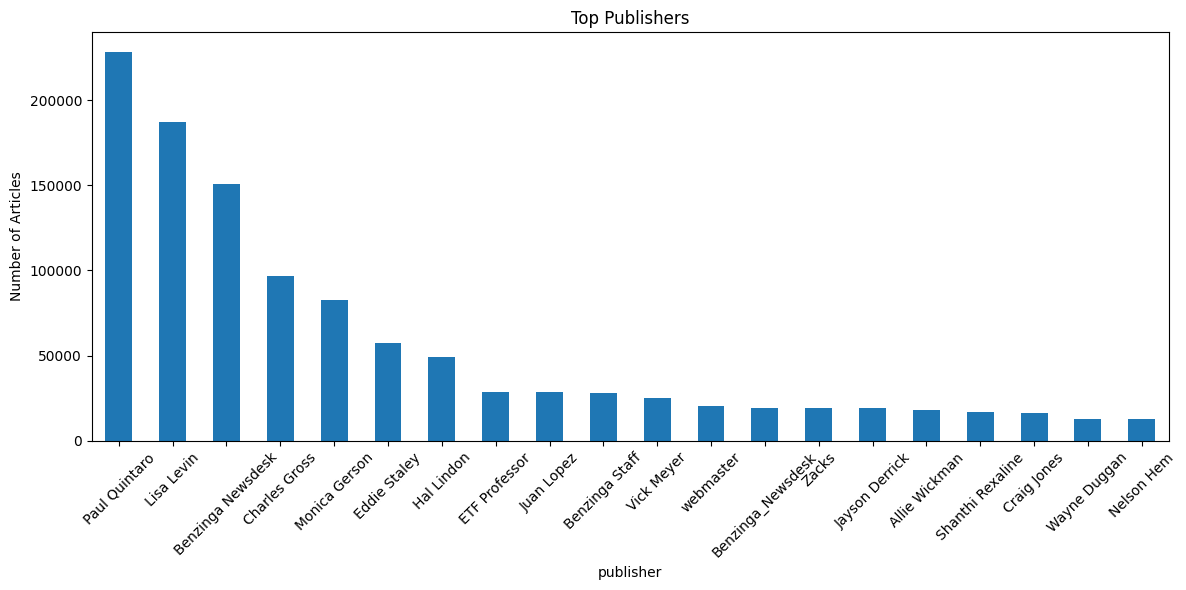

In [6]:
publisher_counts = df["publisher"].value_counts().head(20)

publisher_counts.plot(kind="bar")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.title("Top Publishers")
publisher_counts.plot(kind="bar", figsize=(12,6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conversion of dates

In [7]:
df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
    utc=True,
    errors="coerce"
)

## Daily Articles Count

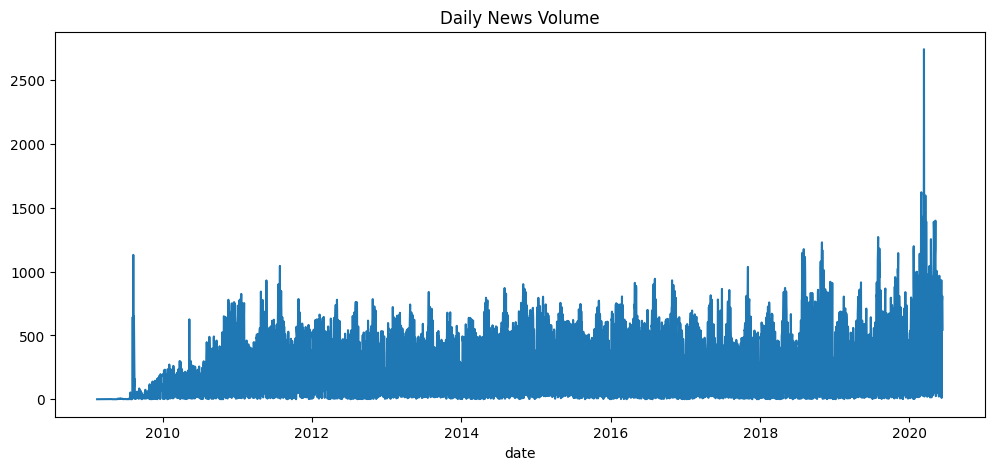

In [8]:
daily_news = df.groupby(df["date"].dt.date).size()

daily_news.plot(figsize=(12,5))
plt.title("Daily News Volume")
plt.show()

## Keywords Analysis

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [10]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df["headline"])

keywords = vectorizer.get_feature_names_out()

print(keywords)

['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']


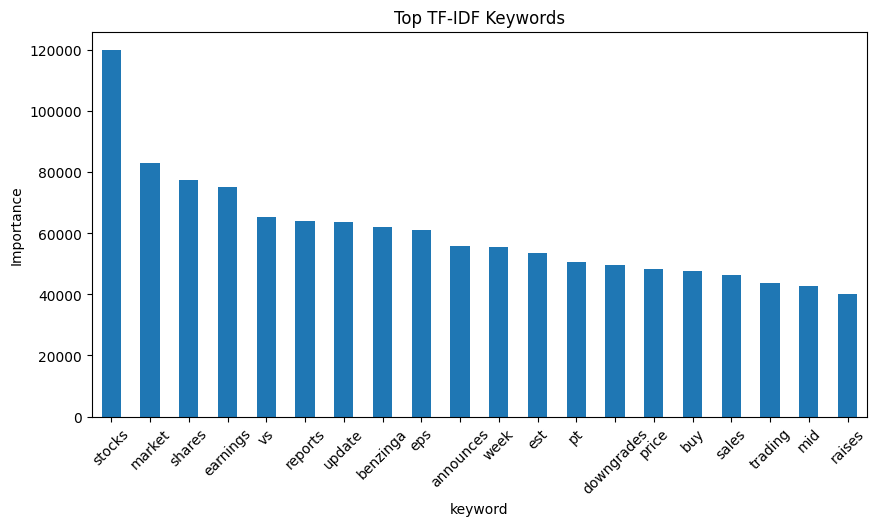

In [11]:
import pandas as pd

keyword_df = pd.DataFrame({
    "keyword": keywords,
    "score": X.sum(axis=0).A1
})

keyword_df = keyword_df.sort_values(by="score", ascending=False)

keyword_df.plot(
    x="keyword",
    y="score",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Top TF-IDF Keywords")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

## Analyze publishing times

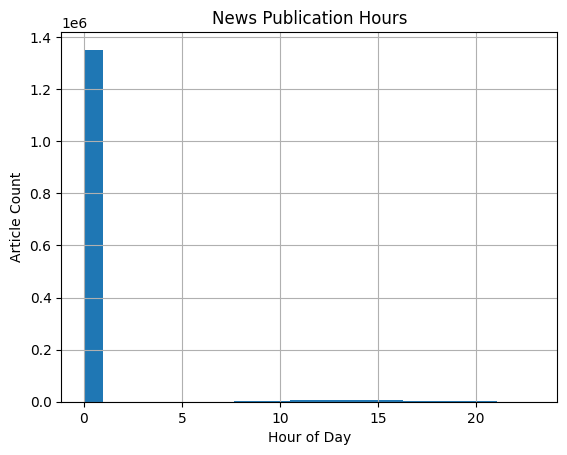

In [12]:
df["hour"] = df["date"].dt.hour

df["hour"].hist(bins=24)

plt.title("News Publication Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Article Count")
plt.show()

## Interpretations
# 1. Basic Exploration of the Dataset

The dataset contains several important columns that help analyze stock-related news and publishing behavior. The main columns identified are:

* **Headline** – contains the news title or summary.
* **Unnamed Column** – appears to be an unnecessary or index-related column.
* **URL** – provides the source link to the article.
* **Publisher** – identifies the organization or individual publishing the news.
* **Date** – shows when the article was published.
* **Stock** – indicates the stock or company related to the news article.

This structure suggests that the dataset is mainly focused on financial news analysis, especially regarding stock market reporting and publishing behavior.

---

# 2. Headline Length Distribution

The second analysis focuses on the **distribution of headline lengths** using a histogram, where:

* **X-axis:** Headline length
* **Y-axis:** Frequency

From the histogram, several observations can be made:

* Headlines with lengths between **20 and 100 characters** have the highest frequency.
* Around the value of **50**, the frequency reaches its peak, with more than **200,000 occurrences**.
* Headlines between **0 and 10 characters** are extremely rare.
* There are almost **no headlines longer than 400 characters**.

This indicates that most headlines are written within a moderate length range, likely because concise headlines are more effective for financial news reporting. The concentration around 20–100 characters suggests that publishers prefer headlines that are informative but still short enough to quickly capture attention.

---

# 3. Analysis of Top Publishers and Common Keywords

The dataset also reveals several recurring publisher names and commonly used financial terms. Some of the observed publisher-related or keyword terms include:

* Paul Quontiero
* Benzinga
* Buy
* Downgrades
* Earnings
* Market
* Reports
* Sales
* Shares
* Trading
* Versus
* Update
* Week

Most of these terms represent common day-to-day business and financial language. Since the dataset is related to stocks, words such as:

* **Stock**
* **Market**
* **Shares**
* **Earnings**
* **Trading**

carry strong importance because they directly relate to stock market activities.

Other frequently occurring terms include:

* EPS
* Announcement
* EST
* PDT
* Price
* Sales
* Raises

Among these, some terms particularly indicate actions or movements in the market. The most important action-oriented words are:

* **Update**
* **Announces**
* **Downgrades**
* **Raises**

These terms are significant because they often signal positive or negative changes in stock performance, company valuation, or investor expectations. For example:

* “Raises” may indicate growth or improved forecasts.
* “Downgrades” may reflect declining expectations or negative sentiment.

Overall, the keyword analysis shows that the dataset strongly reflects real-time financial reporting and stock market communication patterns.

---

# 4. Publishing Time Analysis

The final analysis focuses on publishing times.

The graph shows that almost all publications occur within the **0 to 1-hour range**. Visually, the graph appears highly concentrated in one section, with:

* One extremely tall bar
* The remaining bars positioned very low near the bottom

This creates an uneven distribution and suggests that publishing activity is heavily concentrated within a specific time period.

Such a result may indicate one of the following possibilities:

1. The dataset records publication times in a grouped or limited format.
2. Most news articles are published during a very specific hour window.
3. There may be a formatting or preprocessing issue affecting the time distribution.

Because nearly all observations fall into one category, the graph becomes less informative for understanding broader publishing behavior. Further investigation into the time formatting or grouping method may be necessary to confirm whether this pattern reflects real publishing activity or a data-processing issue.
